#  NSR vs. PLATO passband

### Setup notebook

In [1]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

### Imports

In [2]:
import os
import sys
import h5py
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import periodogram
from scipy.ndimage import median_filter
from zipfile import ZipFile

# PlatoSim
import platosim.plot            as pt
import platosim.utilities       as ut
import platosim.referenceFrames as rf
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

import warnings 
warnings.filterwarnings("ignore")

In [27]:
# User parameters
idir = "/lhome/nicholas/data/platosimPaper/NSR"
cfile = idir + "/starcat_all_SPF_CamVis24_NewCat_targets.ftr"

## Test example of loading LCs

In [4]:
# Load first star only
phot = LightCurve(f"{idir}/000000001", mode="multi")
phot.unpack()

In [5]:
# Fetch all files
filenames = phot.files("hdf5")
filenames

['/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam1.1_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam1.2_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam1.3_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam1.4_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam1.5_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam1.6_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam2.1_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam2.2_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam2.3_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam2.4_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam2.5_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam2.6_Q1.hdf5']

In [6]:
# Load the first light curve
nsr = []
for i in range(len(filenames)):
    lc = LightCurve(filenames[i], mode='single')
    nsr.append(lc.getNSR())

In [7]:
np.mean(nsr)/np.sqrt(len(nsr))

55.170940502909616

In [8]:
lc.getRMS()

100.74856990341748

<IPython.core.display.Javascript object>


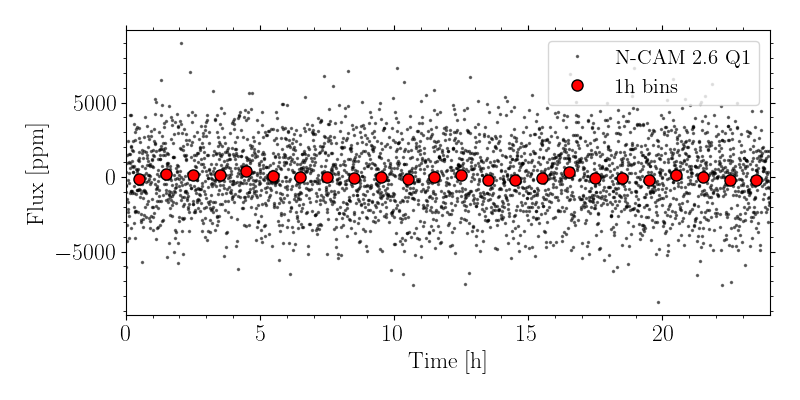

In [14]:
fig, ax = lc.plot(time_unit="h", flux_unit='ppm', binsize=1, alpha=0.5, figsize=(8,4));
# fig.savefig('camera_JitterNone_Star1.png', bbox_inches='tight', dpi=200)

## Analysis of Indiviual N-CAM LCs

In [179]:
phot = LightCurve(idir, mode="multi")
ofile = idir + "/results_per_camera.ftr"

In [83]:
# phot.run_NSRvsMag_analysis_perCamera(ofile, 10000, suffix="hdf5")

In [188]:
# Load results and sort logically
df = pd.read_feather(ofile)

# Load input catalogue
dc = pd.read_feather(cfile)

# Merge the two data frames
mag  = np.array([])
ncon = np.array([])
for i in range(len(dc)):
    nobs = len(df[df.star == i+1])    
    mags = dc.mag.iloc[i] * np.ones(nobs)
    mag  = np.concatenate((mag, mags))
    ncons = dc.ncon.iloc[i] * np.ones(nobs)
    ncon  = np.concatenate((ncon, ncons))                
df["mag"]  = mag
df["ncon"] = ncon

df

,index,star,group,camera,quarter,mag,NSR,ncon
0,0,1,1,1,1,10.618521,194.897888,1.0
1,1,1,1,2,1,10.618521,192.932632,1.0
2,2,1,1,3,1,10.618521,194.348206,1.0
3,3,1,1,4,1,10.618521,187.786850,1.0
4,4,1,1,5,1,10.618521,191.740433,1.0
...,...,...,...,...,...,...,...,...
131947,131947,10000,3,2,1,10.352194,173.179581,0.0
131948,131948,10000,3,3,1,10.352194,175.303558,0.0
131949,131949,10000,3,4,1,10.352194,170.157883,0.0
131950,131950,10000,3,5,1,10.352194,171.576889,0.0


In [181]:
df1 = df.loc[df["ncon"] == 0]
df1

,index,star,group,camera,quarter,mag,NSR,ncon
12,12,2,1,1,1,10.768657,195.958511,0.0
13,13,2,1,2,1,10.768657,198.529892,0.0
14,14,2,1,3,1,10.768657,196.568665,0.0
15,15,2,1,4,1,10.768657,199.532303,0.0
16,16,2,1,5,1,10.768657,197.817841,0.0
...,...,...,...,...,...,...,...,...
131947,131947,10000,3,2,1,10.352194,173.179581,0.0
131948,131948,10000,3,3,1,10.352194,175.303558,0.0
131949,131949,10000,3,4,1,10.352194,170.157883,0.0
131950,131950,10000,3,5,1,10.352194,171.576889,0.0


In [222]:
dx = pd.DataFrame()

for i in range(1, 10001):
    star = df.loc[df["star"] == i]
    ncam = len(star)
    if ncam > 0:
        mag  = star.mag.iloc[0]
        nsr  = star.NSR.mean() / np.sqrt(ncam)
        data = {"mag":mag, "ncam":ncam, "NSR":nsr}
        dx = dx.append(data, ignore_index=True)

print(dx)

            mag  ncam         NSR
0     10.618521  12.0   55.170938
1     10.768657  18.0   47.887326
2     10.060707  12.0   41.931935
3     11.282410  12.0   80.479356
4      9.783687   6.0   50.837814
...         ...   ...         ...
9475   9.182682   6.0   39.229461
9476  11.718769   6.0  146.016726
9477  12.070425   6.0  168.376967
9478  10.369341   6.0   72.141664
9479  10.352194   6.0   71.170000

[9480 rows x 3 columns]


In [345]:
Vmag = ut.passbandConversionV2P(dc.mag, dc.Teff, inverse=True)
df.mag = Vmag
df

,index,star,group,camera,quarter,mag,NSR,ncon
0,0,1,1,1,1,12.051701,194.897888,1.0
1,1,1,1,2,1,12.141105,192.932632,1.0
2,2,1,1,3,1,11.541200,194.348206,1.0
3,3,1,1,4,1,12.688619,187.786850,1.0
4,4,1,1,5,1,11.314703,191.740433,1.0
...,...,...,...,...,...,...,...,...
131947,131947,10000,3,2,1,NaN,173.179581,0.0
131948,131948,10000,3,3,1,NaN,175.303558,0.0
131949,131949,10000,3,4,1,NaN,170.157883,0.0
131950,131950,10000,3,5,1,NaN,171.576889,0.0


<IPython.core.display.Javascript object>


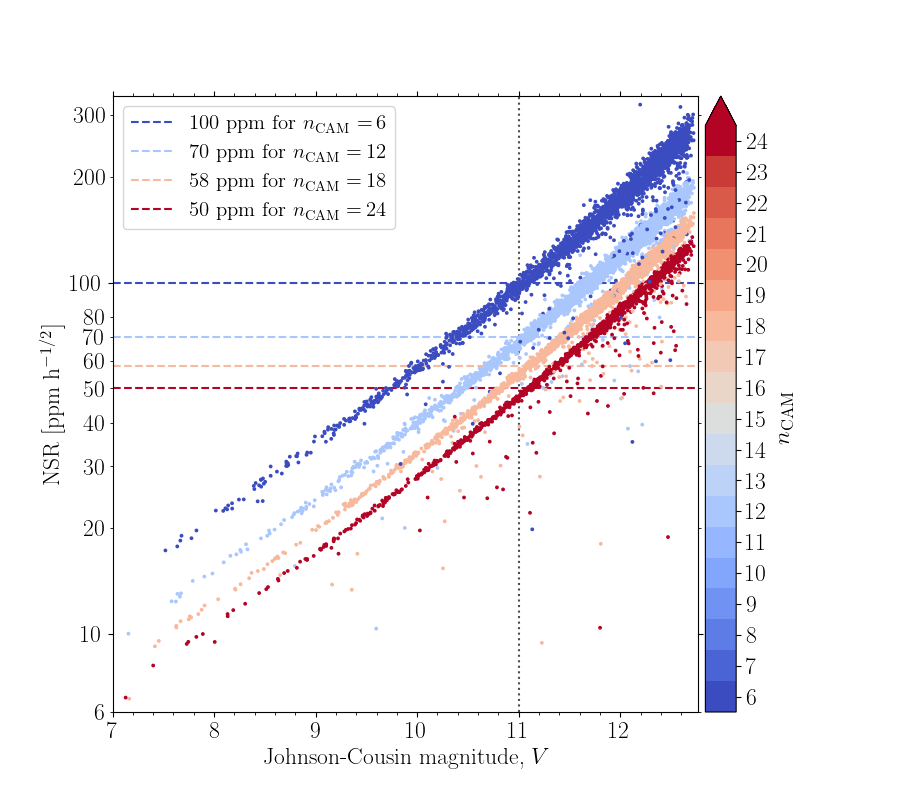

In [348]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(dx, column="ncam", Vmag=True, residuals="multi", 
                                legend=True, grid=False, figsize=(9,8))
ax.set_xlim(7, 12.77)
ax.set_ylim(6, 340)
# We change the fontsize of minor ticks label 
import matplotlib.ticker as mticker
ticks_minor = [5, 6, 20, 30, 40, 50, 60, 70, 80, 200, 300]
ax.yaxis.set_minor_locator(mticker.FixedLocator(ticks_minor))
ax.set_yticklabels(ticks_minor)
ticks_major = [1, 10, 100]
ax.yaxis.set_major_locator(mticker.FixedLocator(ticks_major))
ax.set_yticklabels(ticks_major)
# Save figure
fig.savefig('NSRvsV.png', bbox_inches='tight', dpi=300);

## Analysis of Merged N-CAM LCs

In [134]:
ofile = idir + "/results_per_star.ftr"

In [170]:
phot = LightCurve(idir, mode="multi")
phot.run_NSRvsMag_analysis_perStar(ofile, 500, suffix="hdf5")

100%|██████████████████████████████████████████████████| 500/500 [00:31<00:00, 1


In [172]:
# Load results and sort logically
df = pd.read_feather(ofile)

# Load input catalogue
dc = pd.read_feather(cfile)

# Merge the two data frames
df["mag"]  = dc.mag
df["ncon"] = dc.ncon
df["ncam"] = dc.ncams

# Data without contaminants
df1 = df.loc[df["ncon"] == 0]

<IPython.core.display.Javascript object>


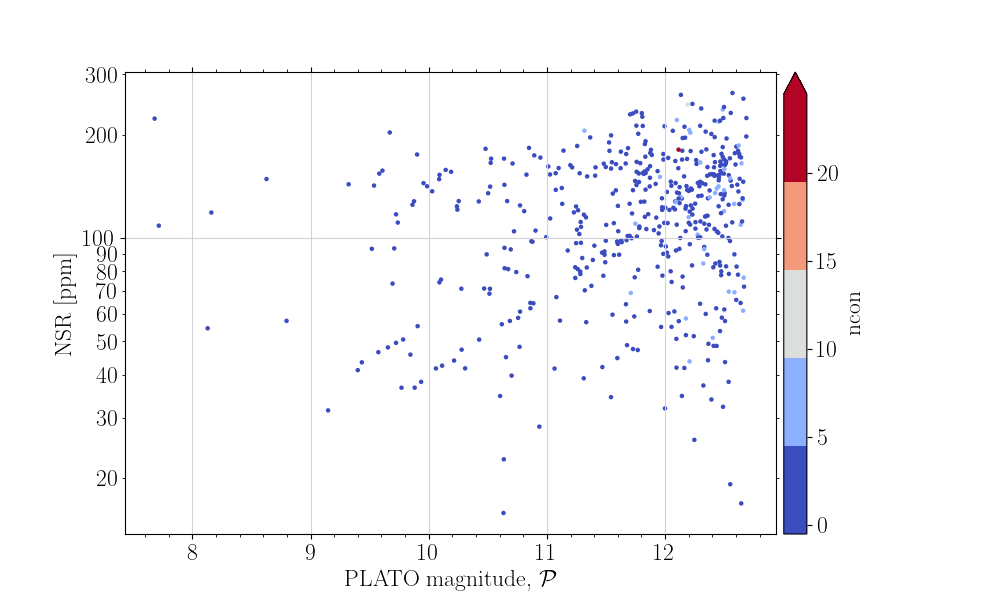

In [173]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, column="ncon", figsize=(10,6))

# Plot one of the outliers
# star = df1.loc[df1["star"] == 316]
# ax.scatter(star["mag"], star["NSR"], s=50, facecolors='none', edgecolors='r');
# fig.savefig('camera_JitterNone_NSR.png', bbox_inches='tight', dpi=200)

# fig.savefig('camera_JitterNone_con_dmag.png', bbox_inches='tight', dpi=200)